c:\Users\HP\anaconda3\envs\rl_env\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 | Reward: -465.00 | Avg: -465.00
Episode 1 | Reward: -396.00 | Avg: -430.50
Episode 2 | Reward: -200.00 | Avg: -353.67
Episode 3 | Reward: -485.00 | Avg: -386.50
Episode 4 | Reward: -475.00 | Avg: -404.20
Episode 5 | Reward: -374.00 | Avg: -399.17
Episode 6 | Reward: -515.00 | Avg: -415.71
Episode 7 | Reward: -352.00 | Avg: -407.75
Episode 8 | Reward: -272.00 | Avg: -392.67
Episode 9 | Reward: -152.00 | Avg: -368.60
Episode 10 | Reward: -595.00 | Avg: -389.18
Episode 11 | Reward: -555.00 | Avg: -403.00
Episode 12 | Reward: -525.00 | Avg: -412.38
Episode 13 | Reward: -296.00 | Avg: -404.07
Episode 14 | Reward: -540.00 | Avg: -413.13
Episode 15 | Reward: -430.00 | Avg: -414.19
Episode 16 | Reward: -525.00 | Avg: -420.71
Episode 17 | Reward: -465.00 | Avg: -423.17
Episode 18 | Reward: -470.00 | Avg: -425.63
Episode 19 | Reward: -535.00 | Avg: -431.10
Episode 20 | Reward: -555.00 | Avg: -437.00
Episode 21 | Reward: -430.00 | Avg: -436.68
Episode 22 | Reward: -110.00 | Avg: -422.4

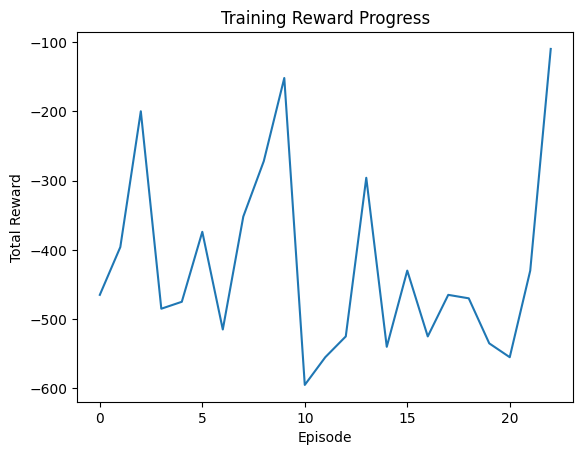

KeyboardInterrupt: 

: 

In [ ]:
# Import libraries (tools we will use)
import gymnasium as gym              # For building RL environments
from gymnasium import spaces         # For defining action/state spaces
import numpy as np                   # Math + arrays
import pygame                         # Graphics
import random                         # Random numbers
import time                           # Delays
import matplotlib.pyplot as plt       # Plot graphs
from collections import deque         # Efficient list for moving average


# ==============================================================================
# CLEANING ROBOT ENVIRONMENT CLASS (OOP)
# ==============================================================================
# In OOP, a class is like a blueprint for creating objects.
# Here, CleaningRobotEnv is a blueprint for our robot world.

class CleaningRobotEnv(gym.Env):

    # Metadata tells gym how fast to update the screen
    metadata = {"render_modes": ["human"], "render_fps": 8}

    # Constructor (runs when object is created)
    def __init__(self, render_mode=None):
        super().__init__()  # Call parent class constructor

        # -----------------------------
        # 1️⃣ GRID SETTINGS
        # -----------------------------

        # Grid size = 5x5 (like chess board but smaller)
        self.grid_size = 5

        # If render_mode="human", we show graphics
        self.render_mode = render_mode

        # Window size in pixels
        self.window_size = 500

        # Size of each grid square
        # Example: 500px / 5 cells = 100px per cell
        self.cell_size = self.window_size // self.grid_size

        # -----------------------------
        # 2️⃣ ACTION SPACE
        # -----------------------------
        # The robot can do 4 actions:
        # 0 = UP, 1 = RIGHT, 2 = DOWN, 3 = LEFT
        self.action_space = spaces.Discrete(4)

        # -----------------------------
        # 3️⃣ DIRT POSITIONS (FIXED)
        # -----------------------------
        # These are coordinates (row, column)
        # Example: (0,4) means top row, last column
        self.dirt_positions = [(0,4), (2,2), (4,4), (4,0)]
        self.num_dirt = len(self.dirt_positions)

        # -----------------------------
        # 4️⃣ OBSERVATION / STATE SPACE
        # -----------------------------
        # State = [row, column, cleaned_mask]
        # cleaned_mask is a binary number showing cleaned dirt
        #
        # Example:
        # mask = 5 = binary 0101 → dirt 0 and dirt 2 cleaned
        self.observation_space = spaces.MultiDiscrete(
            [self.grid_size, self.grid_size, 2**self.num_dirt]
        )

        # -----------------------------
        # 5️⃣ WALLS (robot cannot cross)
        # -----------------------------
        self.walls = [(1,1), (3,1), (2,3)]

        # Pygame variables
        self.window = None
        self.clock = None
        self.font = None

        # Reset environment when created
        self.reset()


    # --------------------------------------------------------------------------
    # RESET FUNCTION
    # Called at the start of every episode (game round)
    # --------------------------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Robot always starts at top-left corner
        self.agent_pos = np.array([0,0])

        # cleaned_mask = 0 means nothing cleaned yet
        self.cleaned_mask = 0

        # Return initial observation (state)
        return self._get_obs(), {}


    # --------------------------------------------------------------------------
    # GET OBSERVATION FUNCTION
    # --------------------------------------------------------------------------
    def _get_obs(self):
        # Return current robot state as array
        return np.array([
            self.agent_pos[0],   # row
            self.agent_pos[1],   # column
            self.cleaned_mask    # cleaning progress
        ])


    # --------------------------------------------------------------------------
    # STEP FUNCTION (MOST IMPORTANT IN RL)
    # It:
    # - Moves robot
    # - Gives reward
    # - Checks if episode is finished
    # --------------------------------------------------------------------------
    def step(self, action):

        # -----------------------------
        # 1️⃣ ACTION → MOVEMENT
        # -----------------------------
        # Dictionary maps action number to movement
        directions = {
            0: np.array([-1,0]),  # UP
            1: np.array([0,1]),   # RIGHT
            2: np.array([1,0]),   # DOWN
            3: np.array([0,-1])   # LEFT
        }

        # Small penalty for every move (encourages faster cleaning)
        reward = -1

        # Calculate new position
        new_pos = self.agent_pos + directions[action]

        # -----------------------------
        # 2️⃣ CHECK WALLS AND BOUNDARIES
        # -----------------------------
        # Robot must stay inside grid and avoid walls
        if (0 <= new_pos[0] < self.grid_size and
            0 <= new_pos[1] < self.grid_size and
            tuple(new_pos) not in self.walls):

            # Valid move → update position
            self.agent_pos = new_pos
        else:
            # Hit wall or outside grid → extra penalty
            reward -= 5


        # -----------------------------
        # 3️⃣ CLEANING LOGIC
        # -----------------------------
        # Check each dirt tile
        for i, dirt in enumerate(self.dirt_positions):

            # If robot is on dirt tile
            if tuple(self.agent_pos) == dirt:

                # If this dirt not cleaned yet
                if not (self.cleaned_mask & (1 << i)):

                    reward += 20  # Big reward for cleaning

                    # Mark dirt as cleaned (turn bit ON)
                    self.cleaned_mask |= (1 << i)

        terminated = False

        # -----------------------------
        # 4️⃣ TERMINAL CONDITION
        # -----------------------------
        # If all dirt cleaned
        if self.cleaned_mask == (2**self.num_dirt - 1):

            # If robot returned to home (0,0)
            if tuple(self.agent_pos) == (0,0):
                reward += 100  # Bonus reward
                terminated = True  # End episode

        return self._get_obs(), reward, terminated, False, {}


    # --------------------------------------------------------------------------
    # RENDER FUNCTION (Graphics)
    # --------------------------------------------------------------------------
    def render(self, episode=None):

        # Initialize pygame only once
        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode(
                (self.window_size, self.window_size)
            )
            self.clock = pygame.time.Clock()
            self.font = pygame.font.SysFont("Arial", 18)

        # Create drawing surface
        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255,255,255))  # White background

        # Draw grid and walls
        for r in range(self.grid_size):
            for c in range(self.grid_size):

                rect = pygame.Rect(
                    c*self.cell_size,
                    r*self.cell_size,
                    self.cell_size,
                    self.cell_size
                )

                # Walls = black squares
                if (r,c) in self.walls:
                    pygame.draw.rect(canvas, (0,0,0), rect)
                else:
                    pygame.draw.rect(canvas, (255,255,255), rect)

                # Grid lines
                pygame.draw.rect(canvas, (200,200,200), rect, 1)

        # Draw dirt (brown squares)
        for i, dirt in enumerate(self.dirt_positions):
            if not (self.cleaned_mask & (1 << i)):
                pygame.draw.rect(
                    canvas,
                    (139,69,19),
                    pygame.Rect(
                        dirt[1]*self.cell_size,
                        dirt[0]*self.cell_size,
                        self.cell_size,
                        self.cell_size
                    )
                )

        # Draw robot (blue circle)
        pygame.draw.circle(
            canvas,
            (0,0,255),
            (
                int((self.agent_pos[1]+0.5)*self.cell_size),
                int((self.agent_pos[0]+0.5)*self.cell_size)
            ),
            self.cell_size//3
        )

        # Show episode number
        if episode is not None:
            text = self.font.render(f"Episode: {episode}", True, (0,0,0))
            canvas.blit(text, (10,10))

        # Update screen
        self.window.blit(canvas, canvas.get_rect())
        pygame.display.update()
        pygame.event.pump()
        self.clock.tick(self.metadata["render_fps"])


    # Close pygame window
    def close(self):
        if self.window:
            pygame.quit()


# ==============================================================================
# TRAINING FUNCTION (Q-Learning)
# ==============================================================================
def train_robot():
    """
    Robot learns using Q-learning (table of best actions).
    """

    env = CleaningRobotEnv(render_mode=None)

    # Q-table dimensions:
    # row × col × cleaned_mask × actions
    q_table = np.zeros((5, 5, 16, 4))

    # Hyperparameters
    episodes = 8000
    alpha = 0.1   # learning speed
    gamma = 0.95  # future reward importance

    epsilon = 1.0        # exploration rate
    min_epsilon = 0.05
    decay = 0.0007

    max_steps = 200

    rewards_history = []
    moving_avg = deque(maxlen=200)

    best_avg = -np.inf
    patience = 20
    no_improve_counter = 0

    render_every = 500


    # ================= TRAINING LOOP =================
    for episode in range(episodes):

        state, _ = env.reset()
        total_reward = 0
        done = False
        step_count = 0

        while not done and step_count < max_steps:

            r, c, mask = state

            # Epsilon-Greedy Action Selection
            if random.uniform(0,1) < epsilon:
                action = env.action_space.sample()  # random move
            else:
                action = np.argmax(q_table[r,c,mask])  # best learned move

            # Perform action
            next_state, reward, done, _, _ = env.step(action)
            nr, nc, nmask = next_state

            # Q-learning update formula
            old_value = q_table[r,c,mask,action]
            next_max = np.max(q_table[nr,nc,nmask])

            q_table[r,c,mask,action] = (
                old_value + alpha * (reward + gamma * next_max - old_value)
            )

            state = next_state
            total_reward += reward
            step_count += 1

            # Visualize sometimes
            if episode % render_every == 0:
                env.render(episode)

        # Decay exploration
        epsilon = max(min_epsilon, epsilon * np.exp(-decay))

        rewards_history.append(total_reward)
        moving_avg.append(total_reward)
        avg_reward = np.mean(moving_avg)

        print(f"Episode {episode} | Reward: {total_reward:.2f} | Avg: {avg_reward:.2f}")

        # Early stopping
        if avg_reward > best_avg:
            best_avg = avg_reward
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        if no_improve_counter >= patience:
            print("Early stopping")
            break

    env.close()

    # Plot reward graph
    plt.plot(rewards_history)
    plt.title("Training Reward Progress")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    return q_table


# ==============================================================================
# DEMO FUNCTION (Robot uses learned brain)
# ==============================================================================
def demo(q_table):

    env = CleaningRobotEnv(render_mode="human")
    state, _ = env.reset()
    done = False

    while not done:
        r, c, mask = state
        action = np.argmax(q_table[r,c,mask])  # best action
        state, _, done, _, _ = env.step(action)
        env.render("FINAL POLICY")

    time.sleep(3)
    env.close()


# ==============================================================================
# MAIN PROGRAM
# ==============================================================================
if __name__ == "__main__":
    q = train_robot()   # Train robot brain
    demo(q)             # Show learned behavior